In [16]:
import seaborn as sns
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from adjustText import adjust_text

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

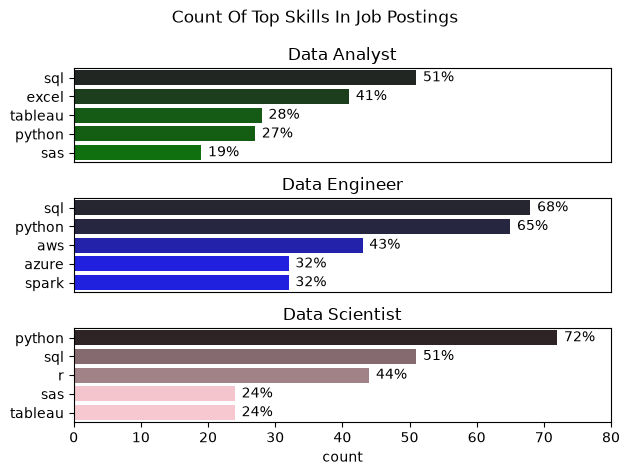

In [ ]:
df = df[df['job_country'] == 'United States']
exploded = df.explode(column='job_skills')

grouped = exploded.groupby(['job_title_short', 'job_skills']).size()
grouped = grouped.to_frame(name='skill_count').reset_index()
grouped = grouped.sort_values(by='skill_count',ascending=False)

job_titles = grouped['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])

count = df['job_title_short'].value_counts().reset_index(name='jobs_total')

skills_perc = pd.merge(grouped,count,how='left',on='job_title_short')
skills_perc['percent'] = (skills_perc['skill_count'] /skills_perc['jobs_total']) * 100
skills_perc['percent'] = skills_perc['percent'].round(0)

fig, ax = plt.subplots(3, 1)

color = ['dark:green_r','dark:blue_r','dark:pink_r']

for i, job_title in enumerate(job_titles):
    plot = (skills_perc[skills_perc['job_title_short'] == job_title].sort_values(ascending=False,by='skill_count').head(5))
    sns.barplot(data=plot,x='percent',y='job_skills',ax=ax[i],hue='skill_count',palette=color[i],legend=False)

    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlim(0, 80)

    for n, v in enumerate(plot['percent']):
        ax[i].text(v + 1,n,f'{v:.0f}%',va='center')

    if i != len(job_titles) - 1:
        ax[i].set_xticks([])
        ax[i].set_xlabel('')

ax[2].set_xlabel('count')
fig.suptitle('Count Of Top Skills In Job Postings')
plt.tight_layout()
plt.show()